In [1]:
#importação bibliotecas
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#lendo as imagens
img_modelo = cv2.imread("livro.jpg") #imagem de referencia 
img_foto = cv2.imread("livro2.jpeg")  #imagem tirada com o celular 

#passando para escala de cinza
cinza_modelo = cv2.cvtColor(img_modelo, cv2.COLOR_BGR2GRAY)
cinza_foto = cv2.cvtColor(img_foto, cv2.COLOR_BGR2GRAY)

Text(0.5, 1.0, 'Pontos de interesse detectados')

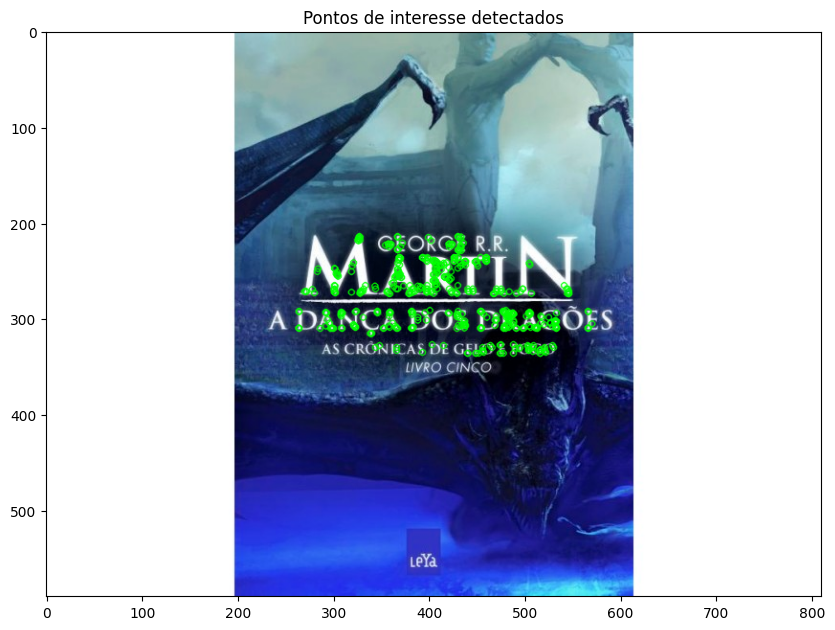

In [3]:
#criando o detector ORB 
orb = cv2.ORB_create(500)
pontos_modelo, descritores_modelo = orb.detectAndCompute(cinza_modelo, None)
pontos_foto, descritores_foto = orb.detectAndCompute(cinza_foto, None)

#desenhando os pontos encontrados para conferir
img_pontos = cv2.drawKeypoints(img_modelo, pontos_modelo, None, color=(0,255,0), flags=0)

#plotando os pontos
plt.figure(figsize=(10,10))
plt.imshow(img_pontos)
plt.title("Pontos de interesse detectados")

In [4]:
#criando o matcher
comparador = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
correspondencias = comparador.match(descritores_modelo, descritores_foto, None)

#ordenando as correspondencias
correspondencias = sorted(correspondencias, key = lambda x: x.distance, reverse = False)

#mantendo apenas as 10% melhores
qtd_melhores = int(len(correspondencias) * 0.10)
melhores_correspondencias = correspondencias[:qtd_melhores]

Text(0.5, 1.0, 'Ligação entre os pontos correspondentes')

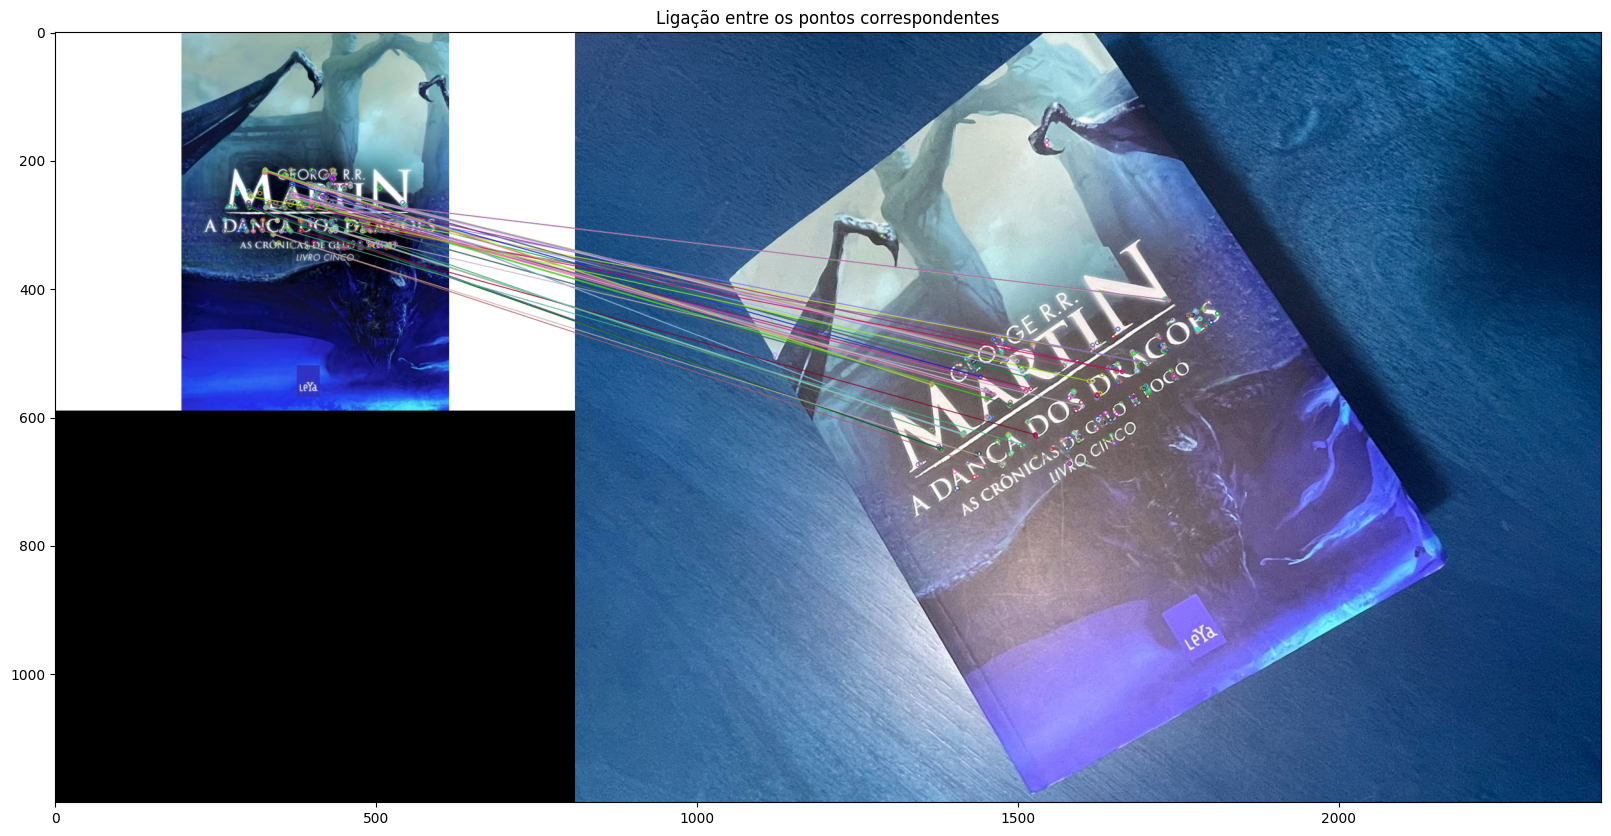

In [5]:
#desenhando as linhas ligando os pontos
img_comparacao = cv2.drawMatches(img_modelo, pontos_modelo, img_foto, pontos_foto, melhores_correspondencias, None)

#plotando o resultado
plt.figure(figsize=(20,10))
plt.imshow(img_comparacao)
plt.title("Ligação entre os pontos correspondentes")

In [6]:
#extranindo as cordenadas dos pontos
pts_modelo = np.zeros((len(melhores_correspondencias), 2), dtype=np.float32)
pts_foto = np.zeros((len(melhores_correspondencias), 2), dtype=np.float32)

for i, m in enumerate(melhores_correspondencias):
    pts_modelo[i, :] = pontos_modelo[m.queryIdx].pt
    pts_foto[i, :] = pontos_foto[m.trainIdx].pt
  
#encontrando a matriz da homografia
matriz_h, mascara = cv2.findHomography(pts_foto, pts_modelo, cv2.RANSAC, 5.0)

#aplicando transformação
altura, largura, canais = img_modelo.shape
img_alinhada = cv2.warpPerspective(img_foto, matriz_h, (largura, altura))

True

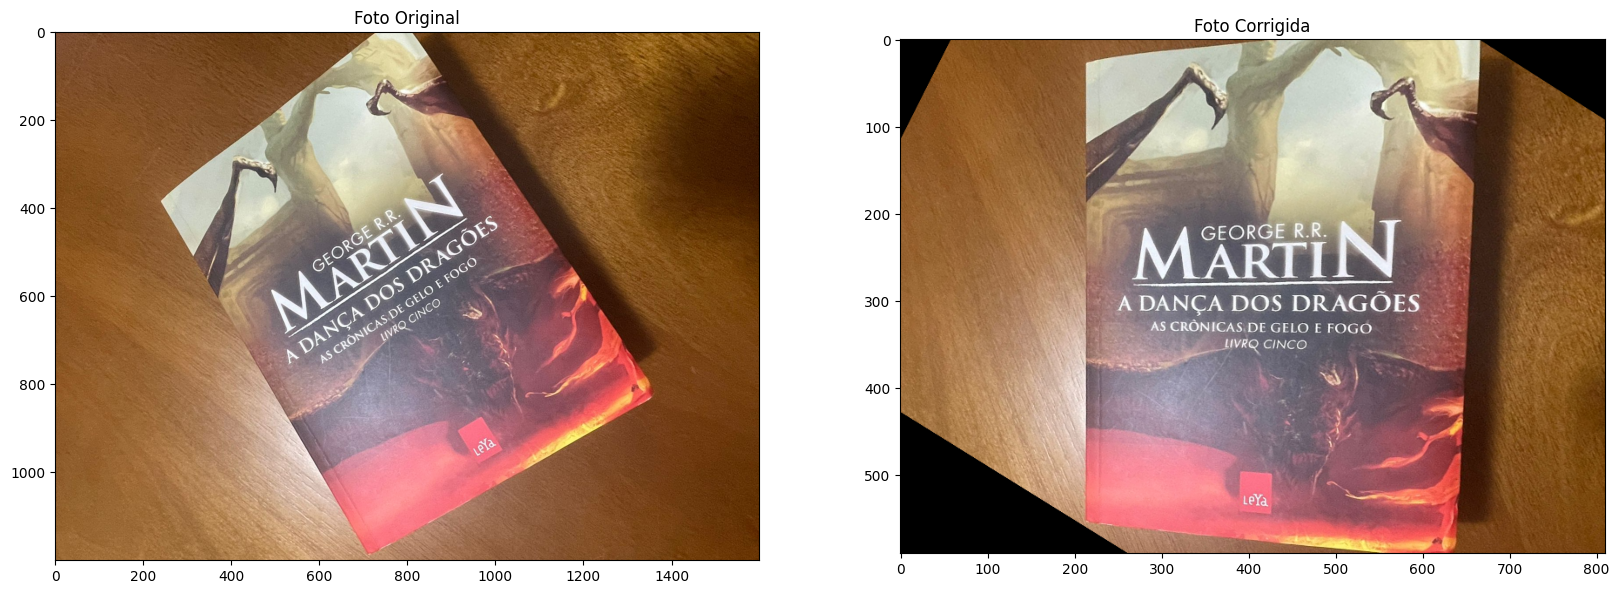

In [8]:
#plotando o resultado final
plt.figure(figsize=(20,10))
plt.subplot(121); plt.imshow(cv2.cvtColor(img_foto, cv2.COLOR_BGR2RGB)); plt.title("Foto Original")
plt.subplot(122); plt.imshow(cv2.cvtColor(img_alinhada, cv2.COLOR_BGR2RGB)); plt.title("Foto Corrigida")

#salvando foto 
cv2.imwrite("resultado_final.jpg", img_alinhada)